# Setup and Import

In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\lebel\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string


# Define paths

In [3]:
DATA_DIR = "D:/multimodal_pipeline/data2"
TRAIN_TSV = os.path.join(DATA_DIR, "D:/multimodal_pipeline/data2/multimodal_train.tsv")
VAL_TSV = os.path.join(DATA_DIR, "D:/multimodal_pipeline/data2/multimodal_validate.tsv")
TEST_TSV = os.path.join(DATA_DIR, "D:/multimodal_pipeline/data2/multimodal_test_public.tsv")


# Load Data

In [4]:
train_df = pd.read_csv(TRAIN_TSV, sep="\t")
val_df = pd.read_csv(VAL_TSV, sep="\t")
test_df = pd.read_csv(TEST_TSV, sep="\t")

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))
train_df.head()


Train samples: 564000
Validation samples: 59342
Test samples: 59319


,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,mildlyinteresting,My Walgreens offbrand Mucinex was engraved wit...,0.84,1,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,pareidolia,This concerned sink with a tiny hat,0.99,0,2,2
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,neutralnews,Hackers leak emails from UAE ambassador to US,0.92,1,0,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,photoshopbattles,PsBattle: Puppy taking in the view,0.95,1,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,pareidolia,I found a face in my sheet music too!,0.84,0,2,2


# Clean text

In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    return text.strip()

for df in [train_df, val_df, test_df]:
    df['clean_text'] = df['clean_title'].apply(clean_text)

train_df[['clean_title', 'clean_text']].head()


,clean_title,clean_text
0,my walgreens offbrand mucinex was engraved wit...,my walgreens offbrand mucinex was engraved wit...
1,this concerned sink with a tiny hat,this concerned sink with a tiny hat
2,hackers leak emails from uae ambassador to us,hackers leak emails from uae ambassador to us
3,puppy taking in the view,puppy taking in the view
4,i found a face in my sheet music too,i found a face in my sheet music too


# Visualise sample images and Text

In [6]:
def get_image_path(row, split="train"):
    return os.path.join(DATA_DIR, f"{split}_images", f"{row['id']}.jpg")

In [7]:
print(get_image_path(train_df.iloc[0], "train"))

D:/multimodal_pipeline/data2\train_images\awxhir.jpg


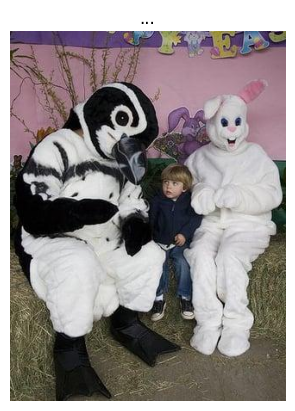

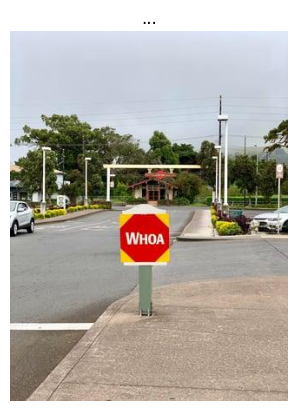

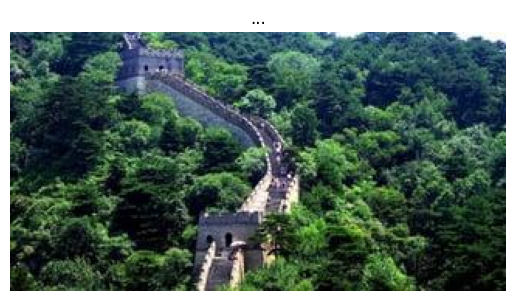

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

def show_samples(df, split="train", n=5):
    samples = df.sample(n)
    for _, row in samples.iterrows():
        img_path = get_image_path(row, split)
        if os.path.exists(img_path):
            img = Image.open(img_path)
            plt.imshow(img)
            plt.axis("off")
            plt.title(row.get("text", "")[:120] + "...")
            plt.show()
        else:
            print(f"Missing: {img_path}")

show_samples(train_df, "train", n=3)

# Explore dataset statistics

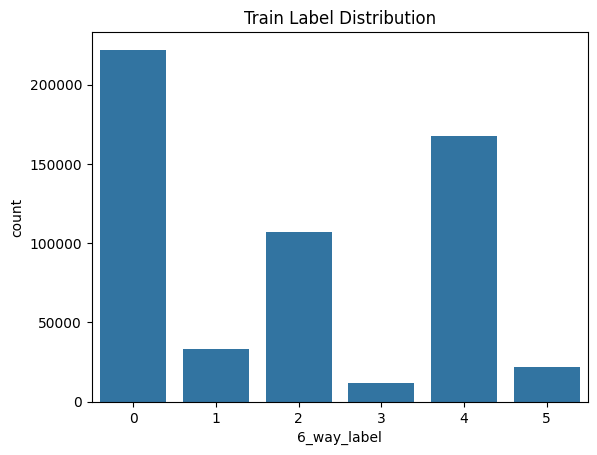

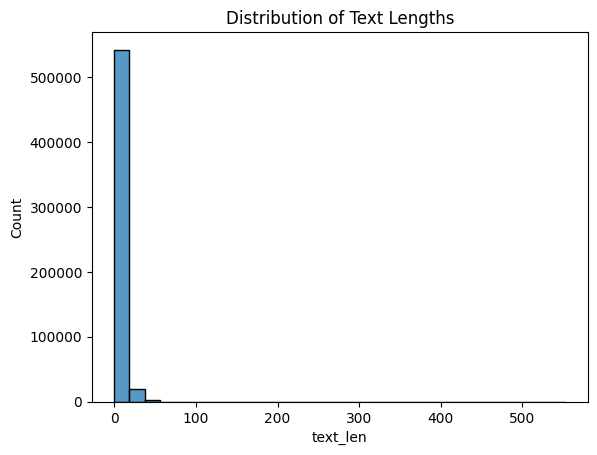

In [9]:
# Label distribution
sns.countplot(x=train_df['6_way_label'])
plt.title("Train Label Distribution")
plt.show()

# Text length distribution
train_df['text_len'] = train_df['clean_text'].apply(lambda x: len(x.split()))
sns.histplot(train_df['text_len'], bins=30)
plt.title("Distribution of Text Lengths")
plt.show()


# Check missing or corrupt Images

In [10]:
import os

train_images_dir = os.path.join(DATA_DIR, "train_images")

missing_images = [
    row['id'] for _, row in train_df.iterrows()
    if not os.path.exists(os.path.join(train_images_dir, f"{row['id']}.jpg"))
]

print(f"Missing images: {len(missing_images)} / {len(train_df)}")



Missing images: 189170 / 564000


In [11]:
import os

train_images_dir = os.path.join(DATA_DIR, "train_images")
print("Number of files in train_images folder:", len(os.listdir(train_images_dir)))

# Check first few files
print("Some example files:", os.listdir(train_images_dir)[:10])


Number of files in train_images folder: 374830
Some example files: ['10012t.jpg', '1001jj.jpg', '10024l.jpg', '1002bi.jpg', '10076s.jpg', '10092l.jpg', '100etx.jpg', '100goj.jpg', '100jh1.jpg', '100k2z.jpg']


In [12]:
print(DATA_DIR)
print(os.path.exists(DATA_DIR))


D:/multimodal_pipeline/data2
True


In [13]:
import os

for root, dirs, files in os.walk(DATA_DIR):
    print(root, "->", len(files), "files")


D:/multimodal_pipeline/data2 -> 3 files
D:/multimodal_pipeline/data2\checkpoints -> 6 files
D:/multimodal_pipeline/data2\failed_downloads -> 3 files
D:/multimodal_pipeline/data2\test_images -> 39617 files
D:/multimodal_pipeline/data2\train_images -> 374830 files
D:/multimodal_pipeline/data2\validate_images -> 39343 files


# Save cleaned metadata

In [14]:
train_df.to_csv(os.path.join(DATA_DIR, "train_metadata_clean.csv"), index=False)
val_df.to_csv(os.path.join(DATA_DIR, "val_metadata_clean.csv"), index=False)
test_df.to_csv(os.path.join(DATA_DIR, "test_metadata_clean.csv"), index=False)